In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
abund_mass= pd.read_csv(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\data\abundance_biomass.csv")

In [12]:
# 1. Abundance & Biomass per Site
abund_mass = abund_mass.groupby(['site', 'month']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight', 'sum')
).reset_index()

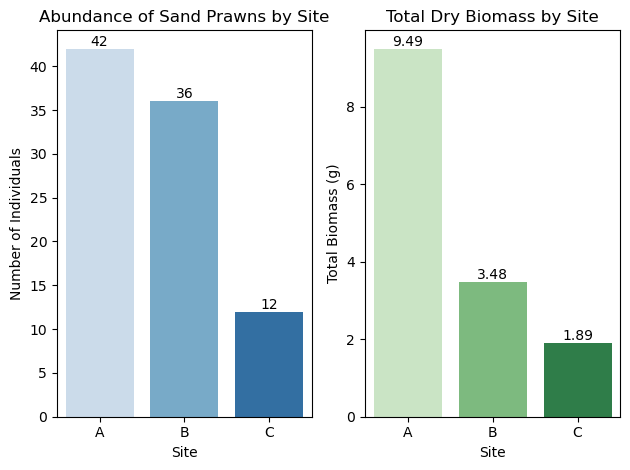

In [22]:
fig, axes = plt.subplots(1, 2)  # side-by-side plots

# Abundance
abundance_ax = sns.barplot(data=abund_mass, x='site', y='abundance', hue='site', palette='Blues', ax=axes[0])
axes[0].set_title('Abundance of Sand Prawns by Site')
axes[0].set_xlabel('Site')
axes[0].set_ylabel('Number of Individuals')

# Add labels to abundance bars
for container in abundance_ax.containers:
    abundance_ax.bar_label(container, fmt="%.0f")  # %.0f = no decimals

# Biomass
biomass_ax = sns.barplot(data=abund_mass, x='site', y='biomass', hue='site', palette='Greens', ax=axes[1])
axes[1].set_title('Total Dry Biomass by Site')
axes[1].set_xlabel('Site')
axes[1].set_ylabel('Total Biomass (g)')

# Add labels to biomass bars
for container in biomass_ax.containers:
    biomass_ax.bar_label(container, fmt="%.2f")  # 2 decimals for biomass

plt.tight_layout()
plt.savefig(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\fig\abundance_biomass.png", dpi=500)
plt.show()

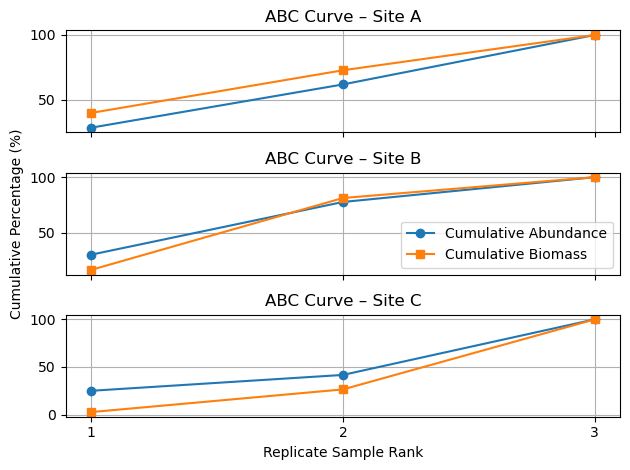

In [25]:
# 2. ABC Curves per Site & Replicate
abund_mass_grouped = abund_mass.groupby(['site', 'replicate']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight', 'sum')
).reset_index()

sites = abund_mass_grouped['site'].unique()
n_sites = len(sites)

fig, axes = plt.subplots(n_sites, 1, sharex=True)

for i, site in enumerate(sites):
    ax = axes[i] if n_sites > 1 else axes
    subset = abund_mass_grouped[abund_mass_grouped['site'] == site].sort_values(by='replicate', ascending=False)
    
    # Cumulative percentages
    subset['cum_abundance'] = subset['abundance'].cumsum() / subset['abundance'].sum() * 100
    subset['cum_biomass'] = subset['biomass'].cumsum() / subset['biomass'].sum() * 100
    
    ax.plot(range(1, len(subset)+1), subset['cum_abundance'], marker='o', label='Cumulative Abundance')
    ax.plot(range(1, len(subset)+1), subset['cum_biomass'], marker='s', label='Cumulative Biomass')
    ax.set_title(f'ABC Curve – Site {site}')
    ax.set_xticks(range(1, len(subset)+1))
    ax.grid(True)

axes[-1].set_xlabel('Replicate Sample Rank')
axes[1].set_ylabel('Cumulative Percentage (%)')
axes[1].legend()
plt.tight_layout()
plt.savefig(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\fig\abc_curve.png", dpi=500)
plt.show()

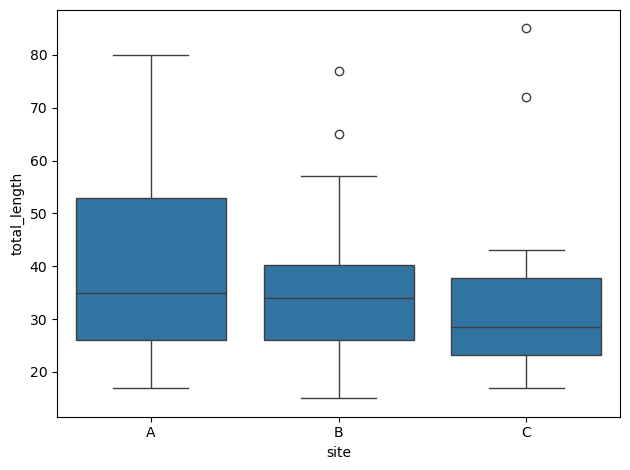

In [29]:
# Ensure you have df defined as your abundance data
df = abund_mass.copy()

# Boxplot: Total Length
sns.boxplot(data=df, x='site', y='total_length')
ax.set_title('Total Length Across Sites')
plt.tight_layout()
plt.savefig(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\fig\boxplot.png", dpi=500)
plt.show()

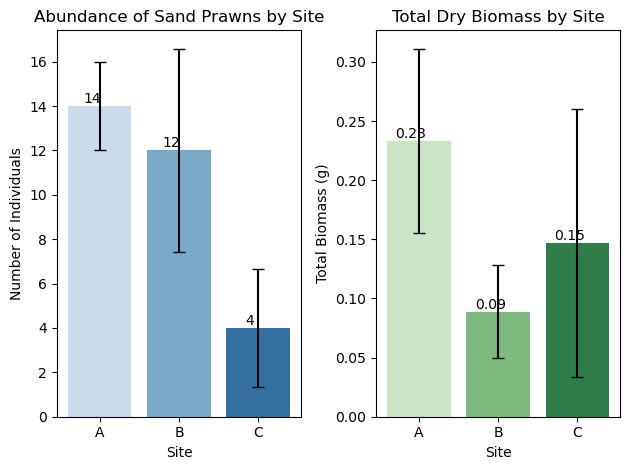

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Aggregate abundance & biomass per replicate
replicate_stats = abund_mass.groupby(['site', 'replicate']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight', 'mean')
).reset_index()

# 2. Compute mean & std across replicates
summary_stats = replicate_stats.groupby(['site']).agg(
    abundance_mean=('abundance', 'mean'),
    abundance_std=('abundance', 'std'),
    biomass_mean=('biomass', 'mean'),
    biomass_std=('biomass', 'std')
).reset_index()

# 3. Plot side-by-side
fig, axes = plt.subplots(1, 2)

# --- Abundance ---
abundance_ax = sns.barplot(
    data=summary_stats, 
    x='site', y='abundance_mean', hue='site',
    palette='Blues', ax=axes[0],
    errorbar=None  # turn off seaborn’s auto errorbars
)

# Add manual error bars
axes[0].errorbar(
    x=range(len(summary_stats['site'])),
    y=summary_stats['abundance_mean'],
    yerr=summary_stats['abundance_std'],
    fmt='none', c='black', capsize=4
)

axes[0].set_title('Abundance of Sand Prawns by Site')
axes[0].set_xlabel('Site')
axes[0].set_ylabel('Number of Individuals')

# Add labels
for i, container in enumerate(abundance_ax.patches):
    # get bar center
    x = container.get_x() + container.get_width()/4
    y = container.get_height()
    # shift horizontally by +0.1 (right) or -0.1 (left)
    abundance_ax.text(x + 0.1, y, f"{summary_stats['abundance_mean'][i]:.0f}", 
                      ha='center', va='bottom', fontsize=10)


# --- Biomass ---
biomass_ax = sns.barplot(
    data=summary_stats,
    x='site', y='biomass_mean', hue='site',
    palette='Greens', ax=axes[1],
    errorbar=None
)

# Add manual error bars
axes[1].errorbar(
    x=range(len(summary_stats['site'])),
    y=summary_stats['biomass_mean'],
    yerr=summary_stats['biomass_std'],
    fmt='none', c='black', capsize=4
)

axes[1].set_title('Total Dry Biomass by Site')
axes[1].set_xlabel('Site')
axes[1].set_ylabel('Total Biomass (g)')

# Add labels
for i, container in enumerate(biomass_ax.patches):
    x = container.get_x() + container.get_width()/4
    y = container.get_height()
    biomass_ax.text(x + 0.1, y, f"{summary_stats['biomass_mean'][i]:.2f}", 
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\fig\abundance_biomass_std.png", dpi=500)
plt.show()